In [1]:
import hoda
import tensorly as tl
import os

%env TENSORLY_BACKEND=numpy
%env CUPY_CUDA_PER_THREAD_DEFAULT_STREAM=1


tl.set_backend(os.environ['TENSORLY_BACKEND'])
tl.get_backend()

env: TENSORLY_BACKEND=numpy
env: CUPY_CUDA_PER_THREAD_DEFAULT_STREAM=1


'numpy'

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
from moabb.paradigms import P300
from moabb.datasets import *


paradigm = P300(resample=48)
dataset = BNCI2014_008()
epochs, labels, meta = paradigm.get_data(
    dataset=dataset, 
     subjects=[1],
     return_epochs=True
)
session = meta['session'][1]
idc = meta['session'] == session
epochs = epochs[idc]
labels = labels[idc]
meta = meta[idc]



/data/leuven/352/vsc35289/miniconda3/envs/bttda/lib/python3.12/site-packages/moabb/datasets/preprocessing.py:279: UserWarning: warnEpochs <Epochs |  4200 events (all good), 0 – 1 s, baseline off, ~65.9 MB, data loaded,
 'Target': 700
 'NonTarget': 3500>
  warn(f"warnEpochs {epochs}")


Adding metadata with 3 columns
Adding metadata with 3 columns
4200 matching events found
No baseline correction applied


/data/leuven/352/vsc35289/miniconda3/envs/bttda/lib/python3.12/site-packages/moabb/paradigms/base.py:350: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  X = mne.concatenate_epochs(X)


In [4]:
import tensorly.decomposition
import matplotlib.pyplot as plt
import tensorly as tl

X = tl.tensor(epochs.get_data())
y = labels

/tmp/ipykernel_3927373/3223033590.py:5: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  X = tl.tensor(epochs.get_data())


In [5]:
#%env PYTHONWARNINGS=error

In [10]:
from sklearn.model_selection import StratifiedKFold
from hoda.hoda import BTTDA, GreedyBTTDA, HODA, trunc_eigh
from hoda.cov import mode_scatter
from sklearn.pipeline import Pipeline
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from mne.decoding import Scaler
import  warnings
from sklearn.model_selection import GridSearchCV
from sklearn.feature_selection import SelectFwe
from sklearn.preprocessing import StandardScaler
import warnings
from joblib import parallel_backend
from joblib import Parallel

bttda = BTTDA(
    ranks=[1,1,1,1,1,1,1,1],
    hoda_params=dict(
        rank=None,
        max_iter=64,
        tol=1e-8,
        init ='random',
        shrinkage='lw',
        toeplitz=None,
        obj='tr',
        solver='lanczos',
        taper=False,
        extra_train_info=False,
        verbose=True,
        random_state=42,
        delta=None,
       
    ),
    verbose=True,
    extra_train_info=True,

)
bttda.fit(X,y)

Fitting block 1/8...


  0%|          | 0/64 [00:00<?, ?it/s]

  0%|          | 0/64 [00:00<?, ?it/s]

         Current function value: 0.886835
         Iterations: 35
Fitting block 2/8...


/data/leuven/352/vsc35289/miniconda3/envs/bttda/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


...

  0%|          | 0/64 [00:00<?, ?it/s]

  0%|          | 0/64 [00:00<?, ?it/s]

         Current function value: 1.274930
         Iterations: 35


/data/leuven/352/vsc35289/miniconda3/envs/bttda/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


BTTDA(extra_train_info=True,
      hoda_params={'delta': None, 'extra_train_info': False, 'init': 'random',
                   'max_iter': 64, 'obj': 'tr', 'random_state': 42, 'rank': 1,
                   'shrinkage': 'lw', 'solver': 'lanczos', 'taper': False,
                   'toeplitz': None, 'tol': 1e-08, 'verbose': True},
      ranks=[1, 1, 1, 1, 1, 1, 1, 1], verbose=True)

In [11]:
import pandas as pd
df = pd.DataFrame(bttda.train_info_)
df

,block,rank,F_tr,F_rt,log_like,pseudo_R2,pseudo_R2_adj,aic,bic,mse,nmse,err_cross_corr
0,1,"(1, 1)",0.000097,0.000193,-3724.708422,-0.968290,-0.968759,7451.416844,7457.759684,1.066769e-10,0.999096,0.000618
1,2,"(1, 1)",0.000097,0.000193,-4464.495269,-1.359225,-1.360349,8932.990538,8945.676218,1.066044e-10,0.998417,0.000109
2,3,"(1, 1)",0.000083,0.000236,-4557.462785,-1.408352,-1.410074,9120.925571,9139.954090,1.064969e-10,0.997410,0.000173
3,4,"(1, 1)",0.000075,0.000236,-4654.476758,-1.459619,-1.461964,9316.953517,9342.324876,1.064789e-10,0.997241,0.000095
4,5,"(1, 1)",0.000059,0.000269,-4753.093777,-1.511732,-1.514726,9516.187553,9547.901752,1.062329e-10,0.994937,0.000157
5,6,"(1, 1)",0.000042,0.000293,-5219.630394,-1.758269,-1.762216,10451.260788,10489.317827,1.060944e-10,0.993640,0.000303
6,7,"(1, 1)",0.000041,0.000296,-5277.373613,-1.788783,-1.793440,10568.747225,10613.147104,1.060556e-10,0.993276,0.000277
7,8,"(1, 1)",0.000038,0.000312,-5354.705998,-1.829649,-1.835050,10725.411997,10776.154715,1.059057e-10,0.991873,0.000276


/data/leuven/352/vsc35289/miniconda3/envs/bttda/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/data/leuven/352/vsc35289/miniconda3/envs/bttda/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='block', ylabel='pseudo_R2_adj'>

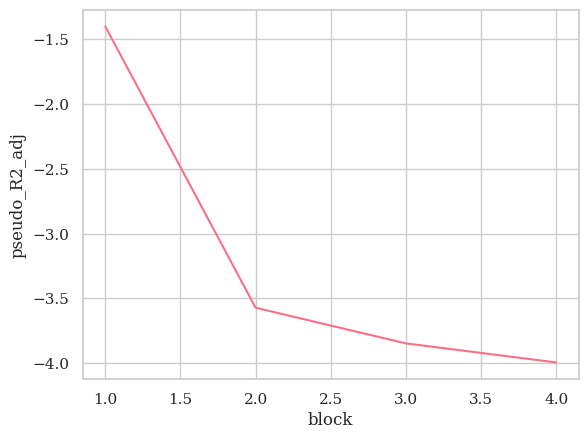

In [9]:
import seaborn as sns
sns.lineplot(data=df, x='block', y='pseudo_R2_adj')